# Estimasi Pelajar yang Dapat Dijangkau (3-6 Bulan)

Tujuan analisis ini adalah menjawab pertanyaan:
**Seberapa banyak pelajar yang dapat dijangkau untuk menjadi pengguna platform organisasi dalam 3-6 bulan ke depan?**

## Alur kerja notebook
1. Load data
2. Assessing data (cek null, duplikat, tipe data)
3. Data cleaning (konversi numerik + fill NaN)
4. EDA dan pemodelan skor jangkauan
5. Visualisasi hasil

In [36]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)

In [37]:
data_siswa_sma_per_provinsi_2025_2026 = pd.read_csv(
    'Data Siswa Sma per Provinsi 2025_2026.csv'
)
data_siswa_sma_per_provinsi_2025_2026.head()

,No.,KD,Provinsi,Tingkat X (Jml),Tingkat X (%),Tingkat XI (Jml),Tingkat XI (%),Tingkat XII (Jml),Tingkat XII (%),Jumlah Total
0,1.0,11,Aceh,48.892,"34,23",48.063,"33,65",45.872,"32,12",142.827
1,2.0,12,Sumatera Utara,131.672,"33,63",131.721,"33,64",128.161,"32,73",391.554
2,3.0,13,Sumatera Barat,57.930,"35,94",53.385,"33,12",49.866,"30,94",161.181
3,4.0,14,Riau,62.948,"34,24",61.872,"33,66",59.000,"32,1",183.820
4,5.0,15,Jambi,29.390,"34,4",28.615,"33,49",27.436,"32,11",85.441


In [38]:
data_angka_putus_sekolah = pd.read_csv(
    'Data Angka Putus Sekolah - Data Angka Putus Sekolah.csv'
)
data_angka_putus_sekolah.head()

,,KD,Provinsi,Negeri (22/23-23/24),Swasta (22/23-23/24),Jumlah (22/23-23/24),Negeri (23/24-24/25),Swasta (23/24-24/25),Jumlah (23/24-24/25),Negeri (24/25-25/26),Swasta (24/25-25/26),Jumlah (24/25-25/26)
0,1.0,11,Aceh,310,43.0,353.000,124,69,193,175,42,217
1,2.0,12,Sumatera Utara,801,920.0,1.721,378,602,980,475,570,1.045
2,3.0,13,Sumatera Barat,128,76.0,204.000,161,47,208,448,24,472
3,4.0,14,Riau,164,26.0,190.000,90,35,125,96,26,122
4,5.0,15,Jambi,110,18.0,128.000,77,4,81,41,6,47


In [39]:
data_jumlah_lulusan_sma = pd.read_csv('Jumlah Lulusan SMA.csv')
data_jumlah_lulusan_sma.head()

,No.,KD,Provinsi,Peserta Laki-laki,Peserta Perempuan,Peserta Jumlah,Lulusan Laki-laki,Lulusan Perempuan,Lulusan Jumlah
0,1.0,11,Aceh,20.683,24.370,45.053,20.605,24.332,44.937
1,2.0,12,Sumatera Utara,57.601,70.796,128.397,57.327,70.630,127.957
2,3.0,13,Sumatera Barat,21.807,29.041,50.848,21.753,29.024,50.777
3,4.0,14,Riau,25.520,31.052,56.572,25.480,31.018,56.498
4,5.0,15,Jambi,12.188,14.494,26.682,12.172,14.483,26.655


In [40]:
data_desa_kelurahan_menurut_provinsi_dan_sinyal_internet_seluler_2025 = pd.read_csv(
    'Banyaknya Desa_Kelurahan menurut Provinsi dan Penerimaan\u00a0Sinyal Internet Telepon Seluler, 2025.csv'
)
data_desa_kelurahan_menurut_provinsi_dan_sinyal_internet_seluler_2025.head()

,Provinsi,Desa Kelurahan dengan Penerimaan Sinyal Internet - 3G/H/H+/ EVDO,"Desa Kelurahan dengan Penerimaan Sinyal Internet - 2,5G/E/ GPRS",Desa Kelurahan dengan Penerimaan Sinyal Internet - Tidak Ada,Desa Kelurahan dengan Penerimaan Sinyal Internet - 5G/4G/LTE
0,Aceh,552.0,83.0,38.0,5840.0
1,Sumatera Utara,402.0,138.0,213.0,5360.0
2,Sumatera Barat,45.0,18.0,20.0,1204.0
3,Riau,95.0,38.0,27.0,1710.0
4,Jambi,106.0,30.0,19.0,1431.0


In [41]:
data_persentase_penduduk_akses_internet_berdasarkan_jenjang_pendidikan_2024 = pd.read_csv(
    'Persentase Penduduk Usia 5 Tahun ke Atas  yang Pernah Mengakses Internet dalam 3 Bulan Terakhir menurut Provinsi dan Jenjang Pendidikan yang Sedang Diduduki, 2024.csv',
    skiprows=4,
    names=['Provinsi', 'SD', 'SMP', 'SMA', 'D1-D3', 'S1 ke atas'],
)
data_persentase_penduduk_akses_internet_berdasarkan_jenjang_pendidikan_2024.head()

,Provinsi,SD,SMP,SMA,D1-D3,S1 ke atas
0,ACEH,17.46,19.53,40.60,3.60,18.82
1,SUMATERA UTARA,20.09,18.57,45.34,2.51,13.49
2,SUMATERA BARAT,24.64,19.57,37.00,3.13,15.66
3,RIAU,26.61,21.92,36.52,1.81,13.14
4,JAMBI,27.17,22.26,35.13,1.90,13.54


In [42]:
data_persentase_penduduk_memiliki_menguasai_telepon_seluler_2024 = pd.read_csv(
    'Persentase Penduduk yang Memiliki_Menguasai Telepon Seluler Menurut Provinsi dan Klasifikasi Daerah, 2024.csv',
    skiprows=4,
    names=['Provinsi', 'Perkotaan', 'Perdesaan', 'Perkotaan+Perdesaan'],
)
data_persentase_penduduk_memiliki_menguasai_telepon_seluler_2024.head()

,Provinsi,Perkotaan,Perdesaan,Perkotaan+Perdesaan
0,ACEH,70.57,61.41,64.64
1,SUMATERA UTARA,72.84,62.42,68.43
2,SUMATERA BARAT,73.51,63.13,68.45
3,RIAU,78.39,72.28,74.74
4,JAMBI,75.83,67.37,70.20


In [43]:
kumpulan_data_pertanyaan_bisnis_satu = {
    'data_siswa_sma_per_provinsi_2025_2026': data_siswa_sma_per_provinsi_2025_2026,
    'data_angka_putus_sekolah': data_angka_putus_sekolah,
    'data_jumlah_lulusan_sma': data_jumlah_lulusan_sma,
    'data_desa_kelurahan_menurut_provinsi_dan_sinyal_internet_seluler_2025': data_desa_kelurahan_menurut_provinsi_dan_sinyal_internet_seluler_2025,
    'data_persentase_penduduk_akses_internet_berdasarkan_jenjang_pendidikan_2024': data_persentase_penduduk_akses_internet_berdasarkan_jenjang_pendidikan_2024,
    'data_persentase_penduduk_memiliki_menguasai_telepon_seluler_2024': data_persentase_penduduk_memiliki_menguasai_telepon_seluler_2024,
}

ringkasan_bentuk_data = pd.DataFrame(
    [
        {
            'nama_variabel': nama_data,
            'jumlah_baris': data.shape[0],
            'jumlah_kolom': data.shape[1],
        }
        for nama_data, data in kumpulan_data_pertanyaan_bisnis_satu.items()
    ]
)
ringkasan_bentuk_data

,nama_variabel,jumlah_baris,jumlah_kolom
0,data_siswa_sma_per_provinsi_2025_2026,40,10
1,data_angka_putus_sekolah,40,12
2,data_jumlah_lulusan_sma,40,9
3,data_desa_kelurahan_menurut_provinsi_dan_sinya...,42,5
4,data_persentase_penduduk_akses_internet_berdas...,39,6
5,data_persentase_penduduk_memiliki_menguasai_te...,39,4


## ASSESING DATA

In [44]:
# Cek ringkas: null value dan duplikasi tiap dataset
kumpulan_data_pertanyaan_bisnis_satu = {
    'data_siswa_sma_per_provinsi_2025_2026': data_siswa_sma_per_provinsi_2025_2026,
    'data_angka_putus_sekolah': data_angka_putus_sekolah,
    'data_jumlah_lulusan_sma': data_jumlah_lulusan_sma,
    'data_desa_kelurahan_menurut_provinsi_dan_sinyal_internet_seluler_2025': data_desa_kelurahan_menurut_provinsi_dan_sinyal_internet_seluler_2025,
    'data_persentase_penduduk_akses_internet_berdasarkan_jenjang_pendidikan_2024': data_persentase_penduduk_akses_internet_berdasarkan_jenjang_pendidikan_2024,
    'data_persentase_penduduk_memiliki_menguasai_telepon_seluler_2024': data_persentase_penduduk_memiliki_menguasai_telepon_seluler_2024,
}

for nama_data, df in kumpulan_data_pertanyaan_bisnis_satu.items():
    print(f'\n=== Pemeriksaan: {nama_data} ===')
    display(df.isnull().sum().to_frame('jumlah_null'))
    print('Jumlah baris duplikat:', df.duplicated().sum())


=== Pemeriksaan: data_siswa_sma_per_provinsi_2025_2026 ===


,jumlah_null
No.,1
KD,1
Provinsi,0
Tingkat X (Jml),0
Tingkat X (%),0
Tingkat XI (Jml),0
Tingkat XI (%),0
Tingkat XII (Jml),0
Tingkat XII (%),0
Jumlah Total,0


Jumlah baris duplikat: 0

=== Pemeriksaan: data_angka_putus_sekolah ===


,jumlah_null
,1
KD,1
Provinsi,0
Negeri (22/23-23/24),0
Swasta (22/23-23/24),0
Jumlah (22/23-23/24),0
Negeri (23/24-24/25),0
Swasta (23/24-24/25),0
Jumlah (23/24-24/25),0
Negeri (24/25-25/26),0


Jumlah baris duplikat: 0

=== Pemeriksaan: data_jumlah_lulusan_sma ===


...

Jumlah baris duplikat: 0

=== Pemeriksaan: data_persentase_penduduk_akses_internet_berdasarkan_jenjang_pendidikan_2024 ===


,jumlah_null
Provinsi,0
SD,0
SMP,0
SMA,0
D1-D3,0
S1 ke atas,0


Jumlah baris duplikat: 0

=== Pemeriksaan: data_persentase_penduduk_memiliki_menguasai_telepon_seluler_2024 ===


,jumlah_null
Provinsi,0
Perkotaan,0
Perdesaan,0
Perkotaan+Perdesaan,0


Jumlah baris duplikat: 0


## Data Cleaning

### Alasan Pengisian Nilai NaN Menjadi 0

Nilai NaN pada data ini diisi dengan `0` karena nilai kosong yang muncul bukan merepresentasikan kehilangan informasi utama, melainkan efek format sumber data (misalnya merge cell pada tabel asal) dan baris/kolom penanda.

Dengan pendekatan ini, struktur data menjadi konsisten untuk proses analisis lanjutan (assessing, EDA, dan visualisasi) tanpa mengubah makna nilai pengukuran yang sebenarnya.

In [45]:
# Ringkasan info dan statistik deskriptif sebelum fill NaN
for nama_data, df in kumpulan_data_pertanyaan_bisnis_satu.items():
    print(f'\n=== INFO dan DESCRIBE: {nama_data} ===')
    df.info()
    display(df.describe(include='all'))


=== INFO dan DESCRIBE: data_siswa_sma_per_provinsi_2025_2026 ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40 entries, 0 to 39
Data columns (total 10 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   No.                39 non-null     float64
 1   KD                 39 non-null     object 
 2   Provinsi           40 non-null     object 
 3   Tingkat X (Jml)    40 non-null     object 
 4   Tingkat X (%)      40 non-null     object 
 5   Tingkat XI (Jml)   40 non-null     object 
 6   Tingkat XI (%)     40 non-null     object 
 7   Tingkat XII (Jml)  40 non-null     object 
 8   Tingkat XII (%)    40 non-null     object 
 9   Jumlah Total       40 non-null     object 
dtypes: float64(1), object(9)
memory usage: 3.3+ KB


,No.,KD,Provinsi,Tingkat X (Jml),Tingkat X (%),Tingkat XI (Jml),Tingkat XI (%),Tingkat XII (Jml),Tingkat XII (%),Jumlah Total
count,39.000000,39,40,40,40,40,40,40,40,40
unique,NaN,39,40,40,38,40,35,40,39,40
top,NaN,11,Aceh,48.892,"33,63",48.063,"33,64",45.872,"33,17",142.827
freq,NaN,1,1,1,2,1,2,1,2,1
mean,20.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
std,11.401754,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
min,1.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
25%,10.500000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
50%,20.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
75%,29.500000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN



=== INFO dan DESCRIBE: data_angka_putus_sekolah ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40 entries, 0 to 39
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0                         39 non-null     float64
 1   KD                    39 non-null     object 
 2   Provinsi              40 non-null     object 
 3   Negeri (22/23-23/24)  40 non-null     object 
 4   Swasta (22/23-23/24)  40 non-null     float64
 5   Jumlah (22/23-23/24)  40 non-null     float64
 6   Negeri (23/24-24/25)  40 non-null     object 
 7   Swasta (23/24-24/25)  40 non-null     object 
 8   Jumlah (23/24-24/25)  40 non-null     object 
 9   Negeri (24/25-25/26)  40 non-null     object 
 10  Swasta (24/25-25/26)  40 non-null     object 
 11  Jumlah (24/25-25/26)  40 non-null     object 
dtypes: float64(3), object(9)
memory usage: 3.9+ KB


,,KD,Provinsi,Negeri (22/23-23/24),Swasta (22/23-23/24),Jumlah (22/23-23/24),Negeri (23/24-24/25),Swasta (23/24-24/25),Jumlah (23/24-24/25),Negeri (24/25-25/26),Swasta (24/25-25/26),Jumlah (24/25-25/26)
count,39.000000,39,40,40,40.000000,40.000000,40,40,40,40,40,40
unique,NaN,39,40,38,NaN,NaN,37,32,38,33,33,39
top,NaN,11,Aceh,55,NaN,NaN,17,-,-,3,-,12
freq,NaN,1,1,2,NaN,NaN,2,4,2,3,3,2
mean,20.000000,NaN,NaN,NaN,108.308200,198.684450,NaN,NaN,NaN,NaN,NaN,NaN
std,11.401754,NaN,NaN,NaN,191.455162,219.994393,NaN,NaN,NaN,NaN,NaN,NaN
min,1.000000,NaN,NaN,NaN,1.000000,1.000000,NaN,NaN,NaN,NaN,NaN,NaN
25%,10.500000,NaN,NaN,NaN,8.500000,43.250000,NaN,NaN,NaN,NaN,NaN,NaN
50%,20.000000,NaN,NaN,NaN,30.000000,121.000000,NaN,NaN,NaN,NaN,NaN,NaN
75%,29.500000,NaN,NaN,NaN,112.000000,258.500000,NaN,NaN,NaN,NaN,NaN,NaN



=== INFO dan DESCRIBE: data_jumlah_lulusan_sma ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40 entries, 0 to 39
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   No.                39 non-null     float64
 1   KD                 39 non-null     object 
 2   Provinsi           40 non-null     object 
 3   Peserta Laki-laki  40 non-null     float64
 4   Peserta Perempuan  40 non-null     float64
 5   Peserta Jumlah     40 non-null     object 
 6   Lulusan Laki-laki  40 non-null     float64
 7   Lulusan Perempuan  40 non-null     float64
 8   Lulusan Jumlah     40 non-null     object 
dtypes: float64(5), object(4)
memory usage: 2.9+ KB


...

,Provinsi,Desa Kelurahan dengan Penerimaan Sinyal Internet - 3G/H/H+/ EVDO,"Desa Kelurahan dengan Penerimaan Sinyal Internet - 2,5G/E/ GPRS",Desa Kelurahan dengan Penerimaan Sinyal Internet - Tidak Ada,Desa Kelurahan dengan Penerimaan Sinyal Internet - 5G/4G/LTE
count,41,38.000000,36.000000,33.000000,39.000000
unique,41,NaN,NaN,NaN,NaN
top,Aceh,NaN,NaN,NaN,NaN
freq,1,NaN,NaN,NaN,NaN
mean,NaN,250.526316,105.333333,210.242424,3795.589744
std,NaN,761.539008,312.840900,641.634097,11721.910565
min,NaN,1.000000,1.000000,1.000000,245.000000
25%,NaN,48.250000,15.750000,19.000000,679.500000
50%,NaN,94.500000,30.000000,34.000000,1204.000000
75%,NaN,160.500000,74.750000,85.000000,2251.000000



=== INFO dan DESCRIBE: data_persentase_penduduk_akses_internet_berdasarkan_jenjang_pendidikan_2024 ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 39 entries, 0 to 38
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Provinsi    39 non-null     object 
 1   SD          39 non-null     float64
 2   SMP         39 non-null     float64
 3   SMA         39 non-null     float64
 4   D1-D3       39 non-null     float64
 5   S1 ke atas  39 non-null     float64
dtypes: float64(5), object(1)
memory usage: 2.0+ KB


,Provinsi,SD,SMP,SMA,D1-D3,S1 ke atas
count,39,39.000000,39.000000,39.000000,39.000000,39.000000
unique,39,NaN,NaN,NaN,NaN,NaN
top,ACEH,NaN,NaN,NaN,NaN,NaN
freq,1,NaN,NaN,NaN,NaN,NaN
mean,NaN,23.849744,20.462564,37.296410,2.698205,15.692821
std,NaN,5.906142,2.903397,5.088529,1.100509,3.796957
min,NaN,11.620000,14.640000,28.610000,1.680000,9.360000
25%,NaN,19.150000,18.585000,34.775000,2.065000,13.115000
50%,NaN,24.940000,20.570000,36.460000,2.350000,15.800000
75%,NaN,28.005000,22.360000,40.760000,3.025000,18.290000



=== INFO dan DESCRIBE: data_persentase_penduduk_memiliki_menguasai_telepon_seluler_2024 ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 39 entries, 0 to 38
Data columns (total 4 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Provinsi             39 non-null     object 
 1   Perkotaan            39 non-null     float64
 2   Perdesaan            39 non-null     object 
 3   Perkotaan+Perdesaan  39 non-null     float64
dtypes: float64(2), object(2)
memory usage: 1.3+ KB


,Provinsi,Perkotaan,Perdesaan,Perkotaan+Perdesaan
count,39,39.000000,39,39.000000
unique,39,NaN,39,NaN
top,ACEH,NaN,61.41,NaN
freq,1,NaN,1,NaN
mean,NaN,75.653077,NaN,66.795128
std,NaN,6.301590,NaN,12.104000
min,NaN,47.780000,NaN,15.760000
25%,NaN,73.175000,NaN,64.580000
50%,NaN,75.830000,NaN,68.290000
75%,NaN,79.045000,NaN,71.540000


### Konversi Tipe Data ke Numerik (Sebelum Fill NaN)

Kolom yang seharusnya numerik dikonversi terlebih dahulu agar proses analisis dan agregasi berjalan konsisten.

In [46]:
def ubah_kolom_ke_numerik(dataframe, nama_kolom, jenis_nilai='jumlah'):
    for kolom in nama_kolom:
        if kolom in dataframe.columns:
            data_teks = dataframe[kolom].astype(str).str.strip()

            if jenis_nilai == 'persen':
                # Untuk persen: pertahankan titik desimal, ubah koma desimal ke titik.
                data_bersih = (
                    data_teks
                    .str.replace('%', '', regex=False)
                    .str.replace(',', '.', regex=False)
                    .str.replace(r'[^0-9.-]', '', regex=True)
                )
            else:
                # Untuk jumlah: titik dianggap pemisah ribuan.
                data_bersih = (
                    data_teks
                    .str.replace('.', '', regex=False)
                    .str.replace(',', '.', regex=False)
                    .str.replace(r'[^0-9.-]', '', regex=True)
                )

            dataframe[kolom] = pd.to_numeric(data_bersih, errors='coerce')

In [47]:
# 1) Konversi data_siswa_sma_per_provinsi_2025_2026
kolom_numerik_data_siswa_jumlah = [
    'Tingkat X (Jml)',
    'Tingkat XI (Jml)',
    'Tingkat XII (Jml)',
    'Jumlah Total',
]
kolom_numerik_data_siswa_persen = [
    'Tingkat X (%)',
    'Tingkat XI (%)',
    'Tingkat XII (%)',
]

ubah_kolom_ke_numerik(
    data_siswa_sma_per_provinsi_2025_2026,
    kolom_numerik_data_siswa_jumlah,
    jenis_nilai='jumlah',
)
ubah_kolom_ke_numerik(
    data_siswa_sma_per_provinsi_2025_2026,
    kolom_numerik_data_siswa_persen,
    jenis_nilai='persen',
)

kolom_numerik_data_siswa = kolom_numerik_data_siswa_jumlah + kolom_numerik_data_siswa_persen
print('Tipe data setelah konversi: data_siswa_sma_per_provinsi_2025_2026')
display(data_siswa_sma_per_provinsi_2025_2026[kolom_numerik_data_siswa].dtypes)

Tipe data setelah konversi: data_siswa_sma_per_provinsi_2025_2026


Tingkat X (Jml)        int64
Tingkat XI (Jml)       int64
Tingkat XII (Jml)      int64
Jumlah Total           int64
Tingkat X (%)        float64
Tingkat XI (%)       float64
Tingkat XII (%)      float64
dtype: object

In [48]:
# 2) Konversi data_angka_putus_sekolah
kolom_numerik_data_putus = [
    'Negeri (22/23-23/24)',
    'Swasta (22/23-23/24)',
    'Jumlah (22/23-23/24)',
    'Negeri (23/24-24/25)',
    'Swasta (23/24-24/25)',
    'Jumlah (23/24-24/25)',
    'Negeri (24/25-25/26)',
    'Swasta (24/25-25/26)',
    'Jumlah (24/25-25/26)',
]
ubah_kolom_ke_numerik(data_angka_putus_sekolah, kolom_numerik_data_putus)

print('Tipe data setelah konversi: data_angka_putus_sekolah')
display(data_angka_putus_sekolah[kolom_numerik_data_putus].dtypes)

Tipe data setelah konversi: data_angka_putus_sekolah


Negeri (22/23-23/24)    float64
Swasta (22/23-23/24)      int64
Jumlah (22/23-23/24)      int64
Negeri (23/24-24/25)    float64
Swasta (23/24-24/25)    float64
Jumlah (23/24-24/25)    float64
Negeri (24/25-25/26)    float64
Swasta (24/25-25/26)    float64
Jumlah (24/25-25/26)    float64
dtype: object

In [49]:
# 3) Konversi data_jumlah_lulusan_sma
kolom_numerik_data_lulusan = [
    'Peserta Laki-laki',
    'Peserta Perempuan',
    'Peserta Jumlah',
    'Lulusan Laki-laki',
    'Lulusan Perempuan',
    'Lulusan Jumlah',
]
ubah_kolom_ke_numerik(data_jumlah_lulusan_sma, kolom_numerik_data_lulusan)

print('Tipe data setelah konversi: data_jumlah_lulusan_sma')
display(data_jumlah_lulusan_sma[kolom_numerik_data_lulusan].dtypes)

Tipe data setelah konversi: data_jumlah_lulusan_sma


Peserta Laki-laki    int64
Peserta Perempuan    int64
Peserta Jumlah       int64
Lulusan Laki-laki    int64
Lulusan Perempuan    int64
Lulusan Jumlah       int64
dtype: object

In [50]:
# 4) Konversi data_persentase_penduduk_akses_internet_berdasarkan_jenjang_pendidikan_2024
kolom_numerik_data_akses_internet = [
    'SD',
    'SMP',
    'SMA',
    'D1-D3',
    'S1 ke atas',
]
ubah_kolom_ke_numerik(
    data_persentase_penduduk_akses_internet_berdasarkan_jenjang_pendidikan_2024,
    kolom_numerik_data_akses_internet,
    jenis_nilai='persen',
)

print('Tipe data setelah konversi: data_persentase_penduduk_akses_internet_berdasarkan_jenjang_pendidikan_2024')
display(
    data_persentase_penduduk_akses_internet_berdasarkan_jenjang_pendidikan_2024[
        kolom_numerik_data_akses_internet
    ].dtypes
)

Tipe data setelah konversi: data_persentase_penduduk_akses_internet_berdasarkan_jenjang_pendidikan_2024


SD            float64
SMP           float64
SMA           float64
D1-D3         float64
S1 ke atas    float64
dtype: object

In [51]:
# 5) Konversi data_persentase_penduduk_memiliki_menguasai_telepon_seluler_2024
kolom_numerik_data_telepon = [
    'Perkotaan',
    'Perdesaan',
    'Perkotaan+Perdesaan',
]
ubah_kolom_ke_numerik(
    data_persentase_penduduk_memiliki_menguasai_telepon_seluler_2024,
    kolom_numerik_data_telepon,
    jenis_nilai='persen',
)

print('Tipe data setelah konversi: data_persentase_penduduk_memiliki_menguasai_telepon_seluler_2024')
display(
    data_persentase_penduduk_memiliki_menguasai_telepon_seluler_2024[
        kolom_numerik_data_telepon
    ].dtypes
)

Tipe data setelah konversi: data_persentase_penduduk_memiliki_menguasai_telepon_seluler_2024


Perkotaan              float64
Perdesaan              float64
Perkotaan+Perdesaan    float64
dtype: object

In [52]:
# Fill NaN untuk seluruh dataset
for nama_data, df in kumpulan_data_pertanyaan_bisnis_satu.items():
    df.fillna(0, inplace=True)
    print(f'\nSisa NaN {nama_data}:')
    display(df.isnull().sum().to_frame('jumlah_null'))


Sisa NaN data_siswa_sma_per_provinsi_2025_2026:


,jumlah_null
No.,0
KD,0
Provinsi,0
Tingkat X (Jml),0
Tingkat X (%),0
Tingkat XI (Jml),0
Tingkat XI (%),0
Tingkat XII (Jml),0
Tingkat XII (%),0
Jumlah Total,0



Sisa NaN data_angka_putus_sekolah:


,jumlah_null
,0
KD,0
Provinsi,0
Negeri (22/23-23/24),0
Swasta (22/23-23/24),0
Jumlah (22/23-23/24),0
Negeri (23/24-24/25),0
Swasta (23/24-24/25),0
Jumlah (23/24-24/25),0
Negeri (24/25-25/26),0



Sisa NaN data_jumlah_lulusan_sma:


...

,jumlah_null
Provinsi,0
Desa Kelurahan dengan Penerimaan Sinyal Internet - 3G/H/H+/ EVDO,0
"Desa Kelurahan dengan Penerimaan Sinyal Internet - 2,5G/E/ GPRS",0
Desa Kelurahan dengan Penerimaan Sinyal Internet - Tidak Ada,0
Desa Kelurahan dengan Penerimaan Sinyal Internet - 5G/4G/LTE,0



Sisa NaN data_persentase_penduduk_akses_internet_berdasarkan_jenjang_pendidikan_2024:


,jumlah_null
Provinsi,0
SD,0
SMP,0
SMA,0
D1-D3,0
S1 ke atas,0



Sisa NaN data_persentase_penduduk_memiliki_menguasai_telepon_seluler_2024:


,jumlah_null
Provinsi,0
Perkotaan,0
Perdesaan,0
Perkotaan+Perdesaan,0


## Validasi Setelah Cleaning

In [53]:
# Ringkasan info dan statistik deskriptif setelah fill NaN
for nama_data, df in kumpulan_data_pertanyaan_bisnis_satu.items():
    print(f'\n=== INFO dan DESCRIBE SETELAH FILLNA: {nama_data} ===')
    df.info()
    display(df.describe(include='all'))
    print(df.columns[df.isna().any()].tolist())


=== INFO dan DESCRIBE SETELAH FILLNA: data_siswa_sma_per_provinsi_2025_2026 ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40 entries, 0 to 39
Data columns (total 10 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   No.                40 non-null     float64
 1   KD                 40 non-null     object 
 2   Provinsi           40 non-null     object 
 3   Tingkat X (Jml)    40 non-null     int64  
 4   Tingkat X (%)      40 non-null     float64
 5   Tingkat XI (Jml)   40 non-null     int64  
 6   Tingkat XI (%)     40 non-null     float64
 7   Tingkat XII (Jml)  40 non-null     int64  
 8   Tingkat XII (%)    40 non-null     float64
 9   Jumlah Total       40 non-null     int64  
dtypes: float64(4), int64(4), object(2)
memory usage: 3.3+ KB


,No.,KD,Provinsi,Tingkat X (Jml),Tingkat X (%),Tingkat XI (Jml),Tingkat XI (%),Tingkat XII (Jml),Tingkat XII (%),Jumlah Total
count,40.000000,40,40,4.000000e+01,40.000000,4.000000e+01,40.000000,4.000000e+01,40.000000,4.000000e+01
unique,NaN,40,40,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,NaN,11,Aceh,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,NaN,1,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,19.500000,NaN,NaN,9.348955e+04,34.286250,9.061365e+04,33.639500,8.782180e+04,32.074250,2.719250e+05
std,11.690452,NaN,NaN,2.942247e+05,1.271252,2.848145e+05,1.096297,2.760083e+05,1.395434,8.550284e+05
min,0.000000,NaN,NaN,3.710000e+02,32.290000,3.980000e+02,32.520000,3.800000e+02,28.370000,1.149000e+03
25%,9.750000,NaN,NaN,1.225875e+04,33.630000,1.197950e+04,33.115000,1.104525e+04,31.577500,3.528350e+04
50%,19.500000,NaN,NaN,2.711600e+04,34.040000,2.722950e+04,33.520000,2.664600e+04,32.155000,8.163050e+04
75%,29.250000,NaN,NaN,6.338825e+04,34.762500,6.239600e+04,33.702500,5.981675e+04,33.047500,1.859008e+05


[]

=== INFO dan DESCRIBE SETELAH FILLNA: data_angka_putus_sekolah ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40 entries, 0 to 39
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0                         40 non-null     float64
 1   KD                    40 non-null     object 
 2   Provinsi              40 non-null     object 
 3   Negeri (22/23-23/24)  40 non-null     float64
 4   Swasta (22/23-23/24)  40 non-null     int64  
 5   Jumlah (22/23-23/24)  40 non-null     int64  
 6   Negeri (23/24-24/25)  40 non-null     float64
 7   Swasta (23/24-24/25)  40 non-null     float64
 8   Jumlah (23/24-24/25)  40 non-null     float64
 9   Negeri (24/25-25/26)  40 non-null     float64
 10  Swasta (24/25-25/26)  40 non-null     float64
 11  Jumlah (24/25-25/26)  40 non-null     float64
dtypes: float64(8), int64(2), object(2)
memory usage: 3.9+ KB


,,KD,Provinsi,Negeri (22/23-23/24),Swasta (22/23-23/24),Jumlah (22/23-23/24),Negeri (23/24-24/25),Swasta (23/24-24/25),Jumlah (23/24-24/25),Negeri (24/25-25/26),Swasta (24/25-25/26),Jumlah (24/25-25/26)
count,40.000000,40,40,40.000000,40.000000,40.000000,40.000000,40.000000,40.000000,40.000000,40.000000,40.000000
unique,NaN,40,40,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,NaN,11,Aceh,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,NaN,1,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,19.500000,NaN,NaN,266.450000,1190.200000,2268.450000,177.500000,158.300000,335.800000,179.850000,133.800000,313.650000
std,11.690452,NaN,NaN,835.440493,1973.829692,2465.285514,553.698567,505.730606,1054.074395,566.863731,431.158915,989.679268
min,0.000000,NaN,NaN,0.000000,10.000000,10.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,9.750000,NaN,NaN,29.250000,90.000000,570.000000,22.250000,9.000000,37.750000,14.750000,5.750000,21.000000
50%,19.500000,NaN,NaN,90.000000,380.000000,1595.000000,80.000000,23.000000,133.000000,43.500000,22.000000,92.500000
75%,29.250000,NaN,NaN,181.500000,1185.000000,2817.500000,137.000000,95.250000,208.750000,129.000000,86.750000,207.250000


[]

=== INFO dan DESCRIBE SETELAH FILLNA: data_jumlah_lulusan_sma ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40 entries, 0 to 39
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   No.                40 non-null     float64
 1   KD                 40 non-null     object 
 2   Provinsi           40 non-null     object 
 3   Peserta Laki-laki  40 non-null     int64  
 4   Peserta Perempuan  40 non-null     int64  
 5   Peserta Jumlah     40 non-null     int64  
 6   Lulusan Laki-laki  40 non-null     int64  
 7   Lulusan Perempuan  40 non-null     int64  
 8   Lulusan Jumlah     40 non-null     int64  
dtypes: float64(1), int64(6), object(2)
memory usage: 2.9+ KB


...

[]

=== INFO dan DESCRIBE SETELAH FILLNA: data_persentase_penduduk_akses_internet_berdasarkan_jenjang_pendidikan_2024 ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 39 entries, 0 to 38
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Provinsi    39 non-null     object 
 1   SD          39 non-null     float64
 2   SMP         39 non-null     float64
 3   SMA         39 non-null     float64
 4   D1-D3       39 non-null     float64
 5   S1 ke atas  39 non-null     float64
dtypes: float64(5), object(1)
memory usage: 2.0+ KB


,Provinsi,SD,SMP,SMA,D1-D3,S1 ke atas
count,39,39.000000,39.000000,39.000000,39.000000,39.000000
unique,39,NaN,NaN,NaN,NaN,NaN
top,ACEH,NaN,NaN,NaN,NaN,NaN
freq,1,NaN,NaN,NaN,NaN,NaN
mean,NaN,23.849744,20.462564,37.296410,2.698205,15.692821
std,NaN,5.906142,2.903397,5.088529,1.100509,3.796957
min,NaN,11.620000,14.640000,28.610000,1.680000,9.360000
25%,NaN,19.150000,18.585000,34.775000,2.065000,13.115000
50%,NaN,24.940000,20.570000,36.460000,2.350000,15.800000
75%,NaN,28.005000,22.360000,40.760000,3.025000,18.290000


[]

=== INFO dan DESCRIBE SETELAH FILLNA: data_persentase_penduduk_memiliki_menguasai_telepon_seluler_2024 ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 39 entries, 0 to 38
Data columns (total 4 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Provinsi             39 non-null     object 
 1   Perkotaan            39 non-null     float64
 2   Perdesaan            39 non-null     float64
 3   Perkotaan+Perdesaan  39 non-null     float64
dtypes: float64(3), object(1)
memory usage: 1.3+ KB


,Provinsi,Perkotaan,Perdesaan,Perkotaan+Perdesaan
count,39,39.000000,39.000000,39.000000
unique,39,NaN,NaN,NaN
top,ACEH,NaN,NaN,NaN
freq,1,NaN,NaN,NaN
mean,NaN,75.653077,57.720769,66.795128
std,NaN,6.301590,15.673521,12.104000
min,NaN,47.780000,0.000000,15.760000
25%,NaN,73.175000,58.310000,64.580000
50%,NaN,75.830000,61.470000,68.290000
75%,NaN,79.045000,64.295000,71.540000


[]


## EDA dan Visualisasi - Estimasi Pelajar Terjangkau (3-6 Bulan)

### Definisi metrik yang digunakan
1. **Pelajar aktif** = `jumlah siswa SMA total - angka putus sekolah (24/25-25/26)`
2. **Skor jangkauan** (0-1) dibentuk dari komposit indikator akses:
   - kepemilikan/penguasaan telepon seluler (`40%`)
   - akses internet pada jenjang SMA (`40%`)
   - kesiapan sinyal desa/kelurahan (`20%`)
3. **Estimasi pelajar terjangkau** = `pelajar aktif x skor jangkauan`

### Catatan metodologi
- Bobot `0.4, 0.4, 0.2` adalah **asumsi terarah** untuk estimasi awal, bukan angka kausal final.
- Angka ini digunakan agar hasil per provinsi tetap bisa dibandingkan secara konsisten.
- Data sumber CSV tetap tidak diubah; perhitungan hanya dilakukan di notebook.

In [54]:
# Definisi fungsi helper untuk analisis
def normalisasi_0_1(seri):
    min_val = seri.min()
    max_val = seri.max()

    min_kosong = pd.isna(min_val)
    max_kosong = pd.isna(max_val)
    rentang_nol = max_val == min_val

    if min_kosong or max_kosong or rentang_nol:
        return pd.Series(0.0, index=seri.index)

    return (seri - min_val) / (max_val - min_val)

def bersihkan_provinsi(seri):
    return seri.astype(str).str.strip().str.upper()

In [55]:
# Dataset siswa: jumlah siswa SMA total
df_siswa = pd.DataFrame({
    'Provinsi': bersihkan_provinsi(data_siswa_sma_per_provinsi_2025_2026['Provinsi']),
    'jumlah_siswa_total': pd.to_numeric(
        data_siswa_sma_per_provinsi_2025_2026['Jumlah Total'], errors='coerce'
    ),
})

df_siswa.head()

,Provinsi,jumlah_siswa_total
0,ACEH,142827
1,SUMATERA UTARA,391554
2,SUMATERA BARAT,161181
3,RIAU,183820
4,JAMBI,85441


In [56]:
# Dataset putus sekolah: jumlah putus tahun terbaru
df_putus = pd.DataFrame({
    'Provinsi': bersihkan_provinsi(data_angka_putus_sekolah['Provinsi']),
    'dropout_24_25_25_26': pd.to_numeric(
        data_angka_putus_sekolah['Jumlah (24/25-25/26)'], errors='coerce'
    ),
})

df_putus.head()

,Provinsi,dropout_24_25_25_26
0,ACEH,217.0
1,SUMATERA UTARA,1045.0
2,SUMATERA BARAT,472.0
3,RIAU,122.0
4,JAMBI,47.0


In [57]:
# Dataset telepon: persentase kepemilikan/penguasaan telepon
df_telepon = pd.DataFrame({
    'Provinsi': bersihkan_provinsi(
        data_persentase_penduduk_memiliki_menguasai_telepon_seluler_2024['Provinsi']
    ),
    'persen_telepon': pd.to_numeric(
        data_persentase_penduduk_memiliki_menguasai_telepon_seluler_2024['Perkotaan+Perdesaan'],
        errors='coerce',
    ),
})



print(df_telepon[df_telepon.isna().any(axis=1)])

df_telepon.head()

Empty DataFrame
Columns: [Provinsi, persen_telepon]
Index: []


,Provinsi,persen_telepon
0,ACEH,64.64
1,SUMATERA UTARA,68.43
2,SUMATERA BARAT,68.45
3,RIAU,74.74
4,JAMBI,70.20


In [58]:
# Dataset internet: persentase akses internet jenjang SMA
df_internet = pd.DataFrame({
    'Provinsi': bersihkan_provinsi(
        data_persentase_penduduk_akses_internet_berdasarkan_jenjang_pendidikan_2024['Provinsi']
    ),
    'persen_akses_internet_sma': pd.to_numeric(
        data_persentase_penduduk_akses_internet_berdasarkan_jenjang_pendidikan_2024['SMA'],
        errors='coerce',
    ),
})

df_internet.head()

,Provinsi,persen_akses_internet_sma
0,ACEH,40.60
1,SUMATERA UTARA,45.34
2,SUMATERA BARAT,37.00
3,RIAU,36.52
4,JAMBI,35.13


In [59]:
# Dataset sinyal: rasio desa/kelurahan dengan sinyal 5G/4G/LTE
kolom_sinyal_lte = 'Desa Kelurahan dengan Penerimaan Sinyal Internet - 5G/4G/LTE'
kolom_sinyal_tidak_ada = 'Desa Kelurahan dengan Penerimaan Sinyal Internet - Tidak Ada'

df_sinyal = data_desa_kelurahan_menurut_provinsi_dan_sinyal_internet_seluler_2025.copy()
df_sinyal['Provinsi'] = bersihkan_provinsi(df_sinyal['Provinsi'])
df_sinyal['rasio_sinyal_lte'] = df_sinyal[kolom_sinyal_lte] / (
    df_sinyal[kolom_sinyal_lte] + df_sinyal[kolom_sinyal_tidak_ada]
)
df_sinyal['rasio_sinyal_lte'] = df_sinyal['rasio_sinyal_lte'].clip(lower=0, upper=1)

df_sinyal[['Provinsi', 'rasio_sinyal_lte']].head()

,Provinsi,rasio_sinyal_lte
0,ACEH,0.993535
1,SUMATERA UTARA,0.961780
2,SUMATERA BARAT,0.983660
3,RIAU,0.984456
4,JAMBI,0.986897


In [2]:
# Gabungkan seluruh dataset dan hitung estimasi akhir
analitik_provinsi = (
    df_siswa
    .merge(df_putus, on='Provinsi', how='inner')
    .merge(df_telepon, on='Provinsi', how='left')
    .merge(df_internet, on='Provinsi', how='left')
    .merge(df_sinyal[['Provinsi', 'rasio_sinyal_lte']], on='Provinsi', how='left')
)

# Hanya gunakan level provinsi, bukan agregat nasional atau baris metadata
provinsi_tidak_valid = [
    'INDONESIA',
    '38 PROVINSI',
    'TOTAL',
    'NAN',
    '',
    'LUAR NEGERI',
    'LUAR_NEGARA',
    'LUAR-NEGERI',
    'SUMBER',
]

# Pastikan kolom Provinsi sudah dinormalisasi (uppercase + strip)
analitik_provinsi['Provinsi'] = analitik_provinsi['Provinsi'].astype(str).str.strip().str.upper()

# Terapkan filter
analitik_provinsi = analitik_provinsi[~analitik_provinsi['Provinsi'].isin(provinsi_tidak_valid)]

# Hitung dan tampilkan ringkasan singkat untuk verifikasi
print('Jumlah baris analitik_provinsi (setelah filter):', len(analitik_provinsi))
print('Jumlah provinsi unik (setelah filter):', analitik_provinsi['Provinsi'].nunique())

analitik_provinsi['pelajar_aktif'] = (
    analitik_provinsi['jumlah_siswa_total'] - analitik_provinsi['dropout_24_25_25_26']
).clip(lower=0)

analitik_provinsi['telepon_norm'] = normalisasi_0_1(analitik_provinsi['persen_telepon'])
analitik_provinsi['internet_norm'] = normalisasi_0_1(analitik_provinsi['persen_akses_internet_sma'])
analitik_provinsi['sinyal_norm'] = normalisasi_0_1(analitik_provinsi['rasio_sinyal_lte'])

analitik_provinsi['skor_jangkauan'] = (
    0.4 * analitik_provinsi['telepon_norm']
    + 0.4 * analitik_provinsi['internet_norm']
    + 0.2 * analitik_provinsi['sinyal_norm']
)

analitik_provinsi['estimasi_pelajar_terjangkau'] = (
    analitik_provinsi['pelajar_aktif'] * analitik_provinsi['skor_jangkauan']
).round(0)

hasil_top10 = analitik_provinsi.sort_values(
    by='estimasi_pelajar_terjangkau', ascending=False
).head(10)

display(
    hasil_top10[[
        'Provinsi',
        'jumlah_siswa_total',
        'dropout_24_25_25_26',
        'pelajar_aktif',
        'persen_telepon',
        'persen_akses_internet_sma',
        'rasio_sinyal_lte',
        'skor_jangkauan',
        'estimasi_pelajar_terjangkau',
    ]]
)


NameError: name 'df_siswa' is not defined

## Feature Engineering 

Bagian ini menyiapkan fitur baru untuk memperjelas prioritas provinsi 3-6 bulan ke depan.

Fitur yang dibuat:
1. rasio_dropout: proporsi siswa putus sekolah terhadap jumlah siswa total.
2. indeks_kesiapan_digital: kombinasi sederhana kepemilikan telepon dan akses internet.
3. kategori_kesiapan: segmentasi kesiapan digital (rendah, sedang, tinggi).
4. skor_dropout_rendah: transformasi terbalik dari rasio dropout, sehingga nilai besar berarti kondisi dropout lebih baik (lebih rendah).
5. skor_prioritas_baru: skor gabungan antara kapasitas jangkauan dan kondisi dropout.

In [1]:
# Feature Engineering terintegrasi
latihan_fe = analitik_provinsi.copy()

# 1) Fitur turunan dasar
latihan_fe['rasio_dropout'] = latihan_fe['dropout_24_25_25_26'] / latihan_fe['jumlah_siswa_total']
latihan_fe['indeks_kesiapan_digital'] = (
    0.5 * latihan_fe['persen_telepon']
    + 0.5 * latihan_fe['persen_akses_internet_sma']
)

# 2) Binning kesiapan digital
latihan_fe['kategori_kesiapan'] = pd.qcut(
    latihan_fe['indeks_kesiapan_digital'],
    q=3,
    labels=['rendah', 'sedang', 'tinggi']
)

# 3) Skor dropout terbalik: makin tinggi makin baik (dropout makin rendah)
min_drop = latihan_fe['rasio_dropout'].min()
max_drop = latihan_fe['rasio_dropout'].max()

if max_drop == min_drop:
    latihan_fe['skor_dropout_rendah'] = 1.0
else:
    dropout_norm = (latihan_fe['rasio_dropout'] - min_drop) / (max_drop - min_drop)
    latihan_fe['skor_dropout_rendah'] = 1 - dropout_norm

# 4) Skor prioritas akhir
latihan_fe['skor_prioritas_baru'] = (
    0.7 * latihan_fe['skor_jangkauan']
    + 0.3 * latihan_fe['skor_dropout_rendah']
)

top_prioritas_baru = latihan_fe.sort_values('skor_prioritas_baru', ascending=False).head(10)

display(
    top_prioritas_baru[[
        'Provinsi',
        'skor_jangkauan',
        'skor_dropout_rendah',
        'skor_prioritas_baru',
        'estimasi_pelajar_terjangkau',
        'kategori_kesiapan'
    ]]
)

NameError: name 'analitik_provinsi' is not defined

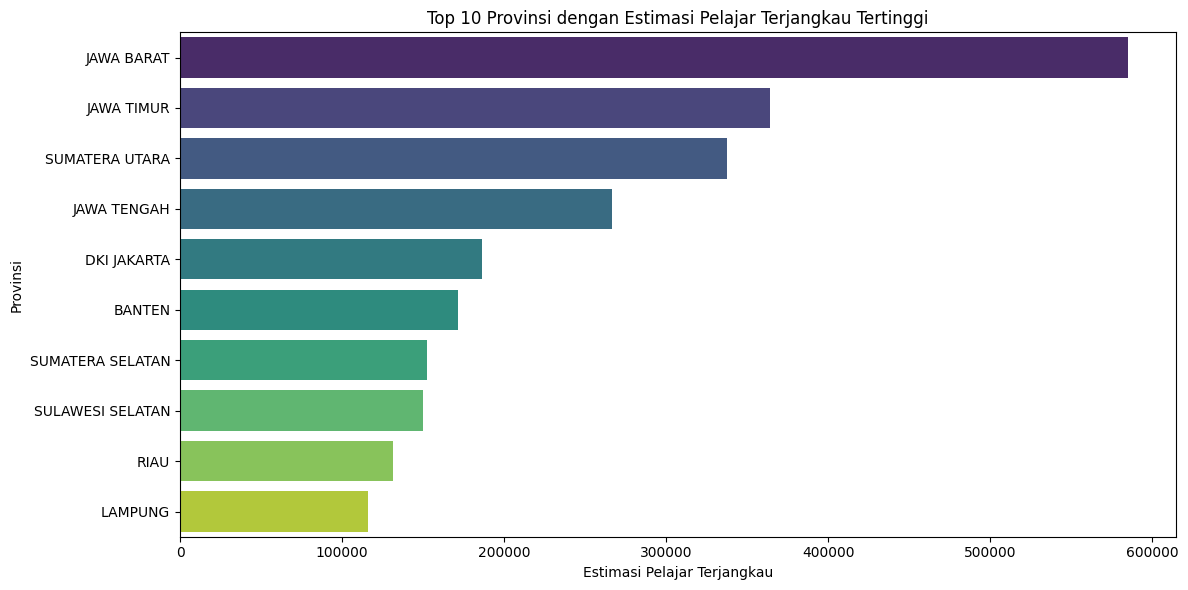

In [72]:
# Visualisasi 1: Top 10 provinsi berdasarkan estimasi pelajar terjangkau sebelum Feature Engineering
plot_top10 = hasil_top10.sort_values('estimasi_pelajar_terjangkau', ascending=False)

plt.figure(figsize=(12, 6))
sns.barplot(
    data=plot_top10,
    x='estimasi_pelajar_terjangkau',
    y='Provinsi',
    hue='Provinsi',
    dodge=False,
    legend=False,
    palette='viridis',
)
plt.title('Top 10 Provinsi dengan Estimasi Pelajar Terjangkau Tertinggi')
plt.xlabel('Estimasi Pelajar Terjangkau')
plt.ylabel('Provinsi')
plt.tight_layout()
plt.show()

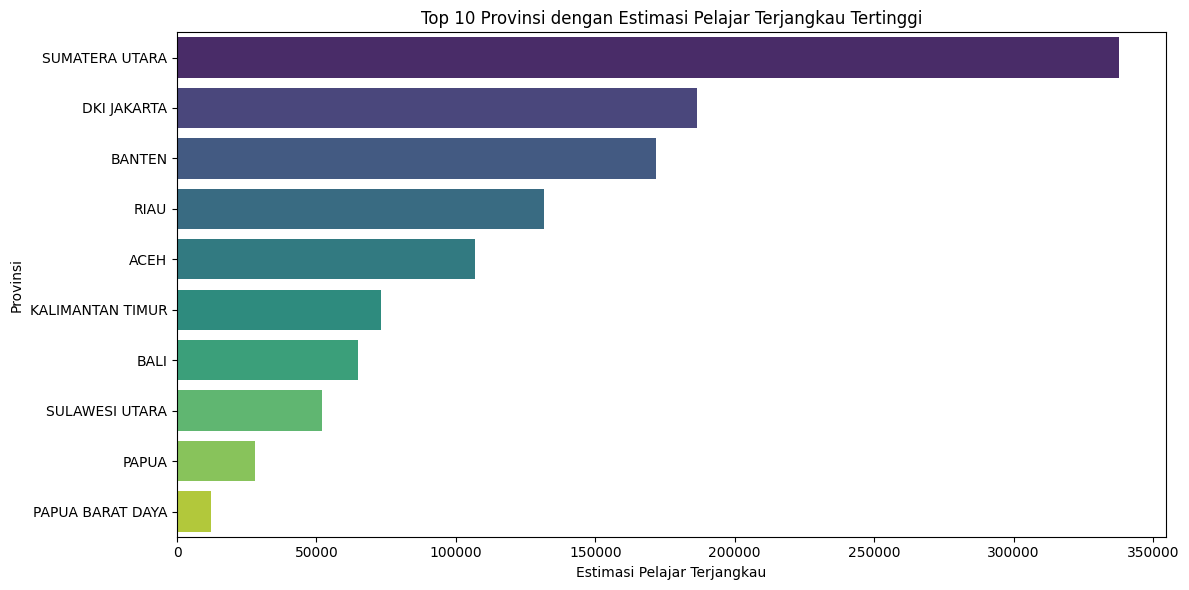

In [ ]:
# Visualisasi 1: Top 10 provinsi berdasarkan estimasi pelajar terjangkau Setelah Feature Engineering
plot_top10 = top_prioritas_baru.sort_values('estimasi_pelajar_terjangkau', ascending=False)

plt.figure(figsize=(12, 6))
sns.barplot(
    data=plot_top10,
    x='estimasi_pelajar_terjangkau',
    y='Provinsi',
    hue='Provinsi',
    dodge=False,
    legend=False,
    palette='viridis',
)
plt.title('Top 10 Provinsi dengan Estimasi Pelajar Terjangkau Tertinggi')
plt.xlabel('Estimasi Pelajar Terjangkau')
plt.ylabel('Provinsi')
plt.tight_layout()
plt.show()

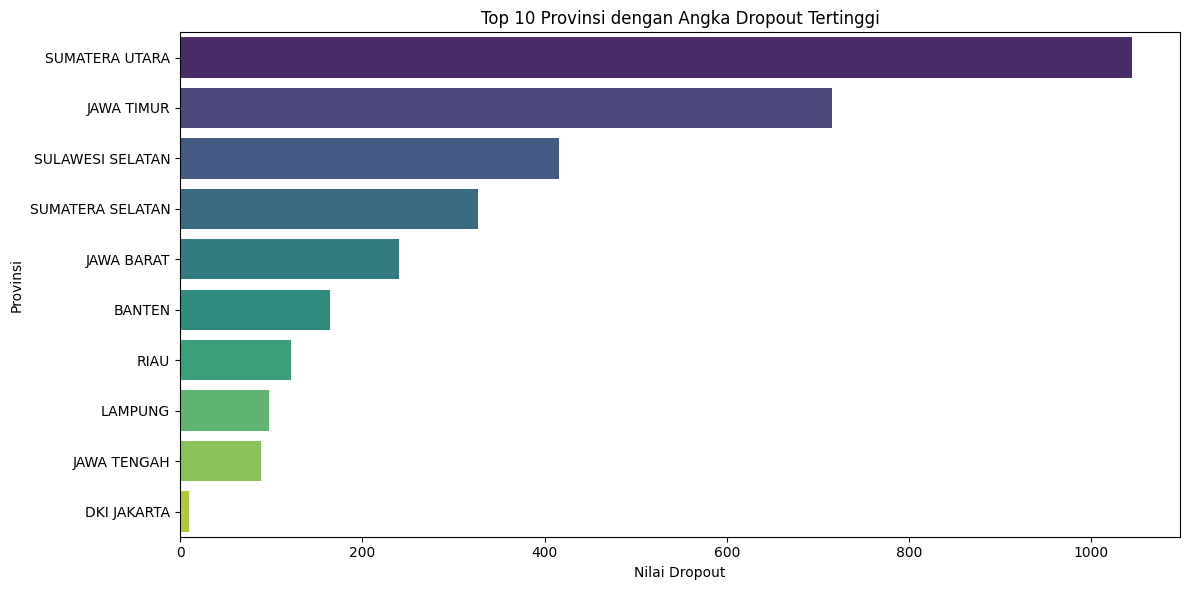

In [ ]:
#visualisasi kota dengan angka dropout yang besar sebelum feature engineering

plot_dropout = hasil_top10.sort_values('dropout_24_25_25_26', ascending=False)

plt.figure(figsize=(12, 6))
sns.barplot(
    data = plot_dropout,
    x='dropout_24_25_25_26',
    y='Provinsi',
    hue='Provinsi',
    dodge=False,
    legend=False,
    palette='viridis',
)
plt.title('Top 10 Provinsi dengan Angka Dropout Terendah')
plt.xlabel('Nilai Dropout')
plt.ylabel('Provinsi')
plt.tight_layout()
plt.show()

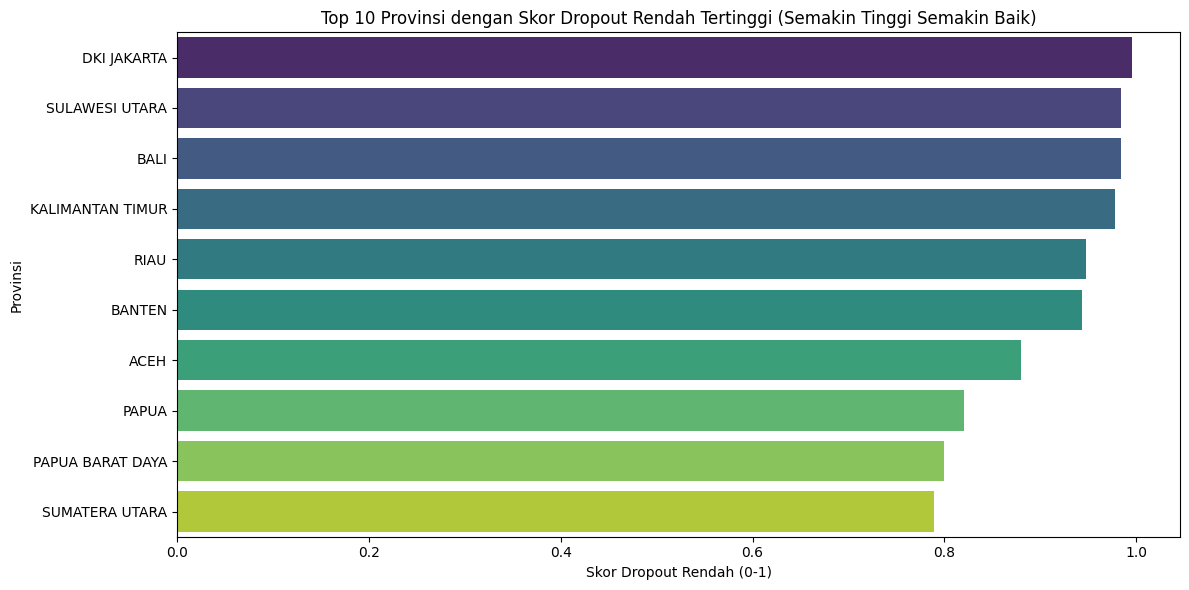

In [80]:
# Visualisasi: Provinsi dengan skor dropout rendah terbaik (setelah feature engineering)
plot_dropout_baik = top_prioritas_baru.sort_values('skor_dropout_rendah', ascending=False)

plt.figure(figsize=(12, 6))
sns.barplot(
    data=plot_dropout_baik,
    x='skor_dropout_rendah',
    y='Provinsi',
    hue='Provinsi',
    dodge=False,
    legend=False,
    palette='viridis',
)
plt.title('Top 10 Provinsi dengan Skor Dropout Rendah Tertinggi (Semakin Tinggi Semakin Baik)')
plt.xlabel('Skor Dropout Rendah (0-1)')
plt.ylabel('Provinsi')
plt.tight_layout()
plt.show()

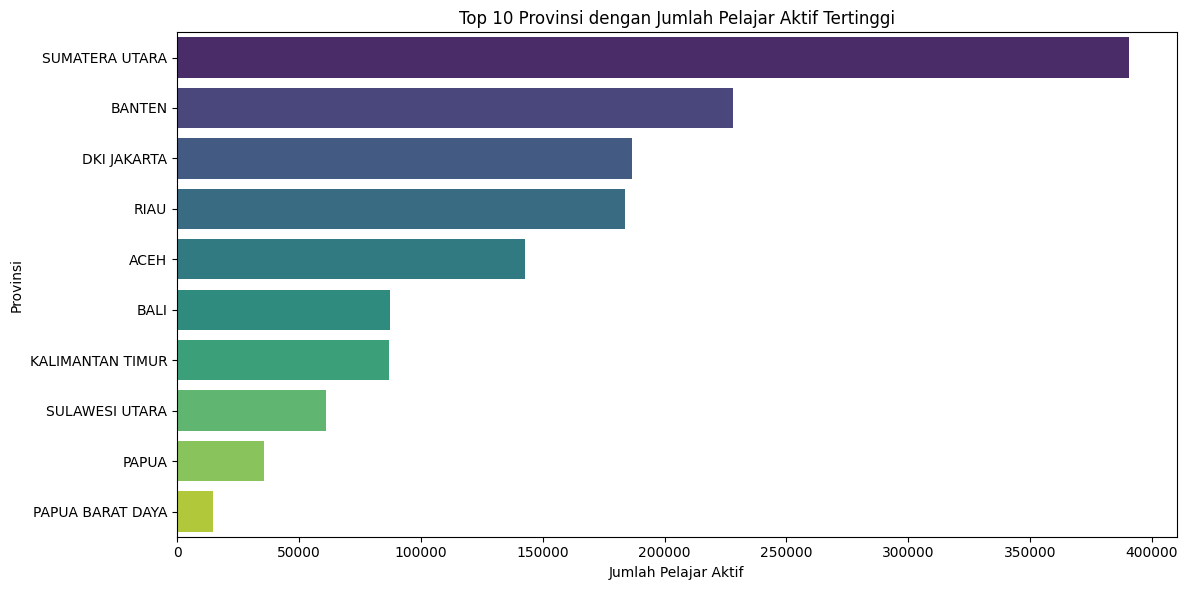

In [81]:
# Visualisasi: Top 10 provinsi berdasarkan jumlah pelajar aktif (setelah feature engineering)
plot_pelajar_aktif = top_prioritas_baru.sort_values('pelajar_aktif', ascending=False)

plt.figure(figsize=(12, 6))
sns.barplot(
    data=plot_pelajar_aktif,
    x='pelajar_aktif',
    y='Provinsi',
    hue='Provinsi',
    dodge=False,
    legend=False,
    palette='viridis',
)
plt.title('Top 10 Provinsi dengan Jumlah Pelajar Aktif Tertinggi')
plt.xlabel('Jumlah Pelajar Aktif')
plt.ylabel('Provinsi')
plt.tight_layout()
plt.show()

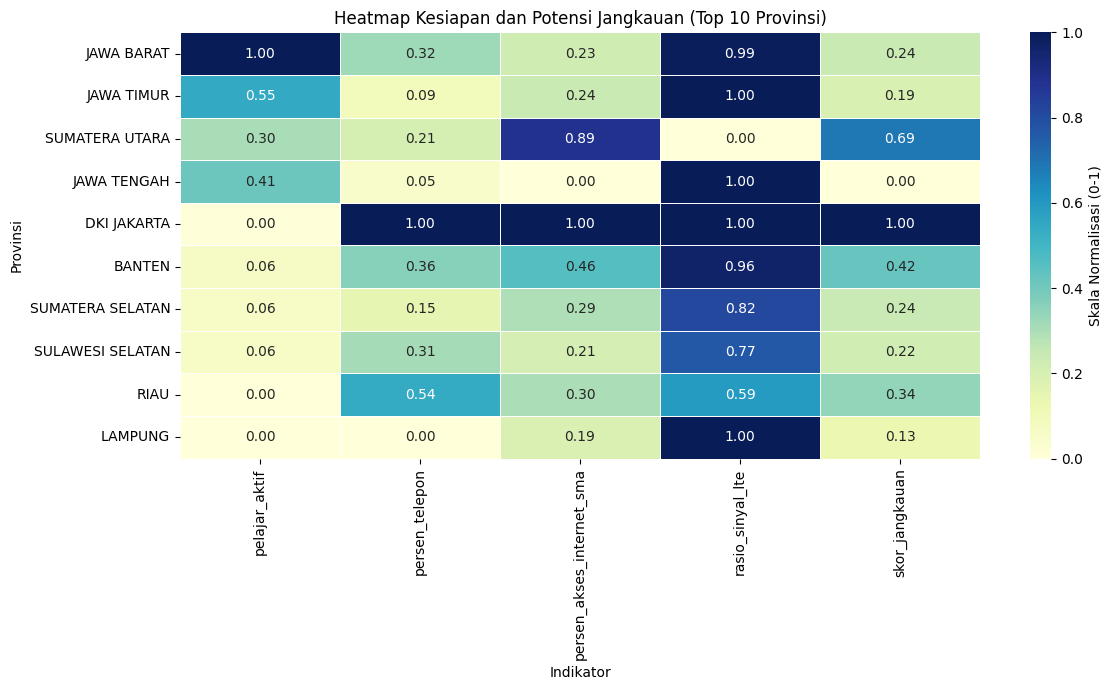

In [ ]:
# Visualisasi 2: Heatmap indikator jangkauan untuk Top 10 provinsi sebelum feature engineering
kolom_heatmap = [
    'pelajar_aktif',
    'persen_telepon',
    'persen_akses_internet_sma',
    'rasio_sinyal_lte',
    'skor_jangkauan',
]

heatmap_data = hasil_top10.set_index('Provinsi')[kolom_heatmap].copy()
heatmap_norm = heatmap_data.apply(normalisasi_0_1)

plt.figure(figsize=(12, 7))
sns.heatmap(
    heatmap_norm,
    cmap='YlGnBu',
    annot=True,
    fmt='.2f',
    linewidths=0.5,
    cbar_kws={'label': 'Skala Normalisasi (0-1)'},
)
plt.title('Heatmap Kesiapan dan Potensi Jangkauan (Top 10 Provinsi)')
plt.xlabel('Indikator')
plt.ylabel('Provinsi')
plt.tight_layout()
plt.show()

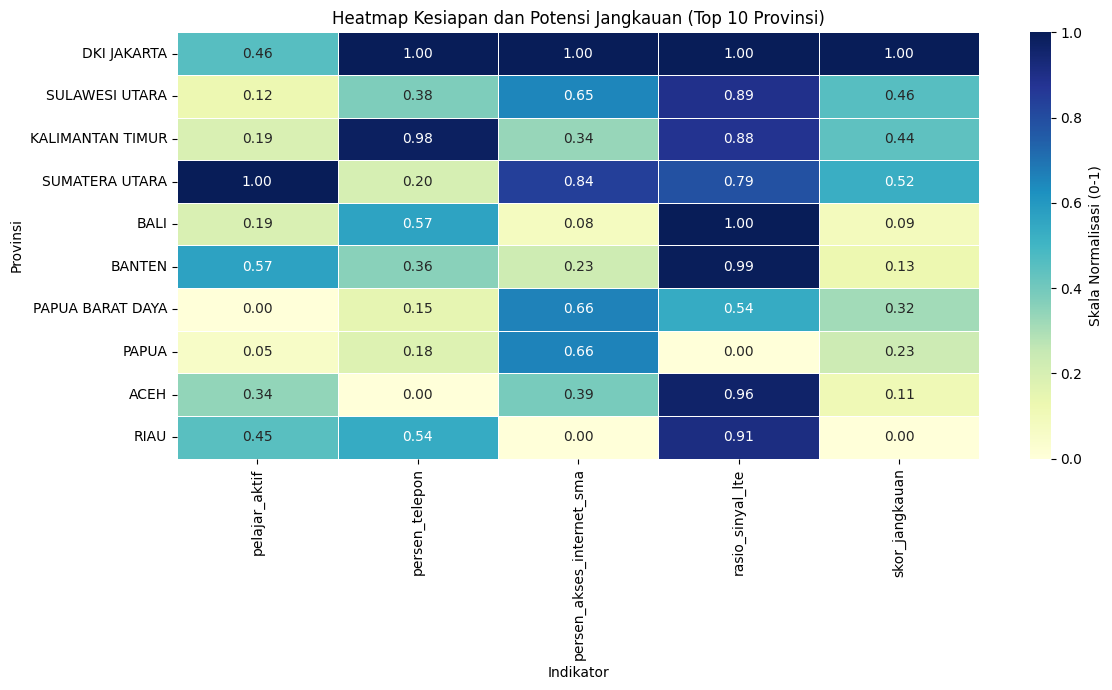

In [75]:
# Visualisasi 2: Heatmap indikator jangkauan untuk Top 10 provinsi setelah feature engineering
kolom_heatmap = [
    'pelajar_aktif',
    'persen_telepon',
    'persen_akses_internet_sma',
    'rasio_sinyal_lte',
    'skor_jangkauan',
]

heatmap_data = top_prioritas_baru.set_index('Provinsi')[kolom_heatmap].copy()
heatmap_norm = heatmap_data.apply(normalisasi_0_1)

plt.figure(figsize=(12, 7))
sns.heatmap(
    heatmap_norm,
    cmap='YlGnBu',
    annot=True,
    fmt='.2f',
    linewidths=0.5,
    cbar_kws={'label': 'Skala Normalisasi (0-1)'},
)
plt.title('Heatmap Kesiapan dan Potensi Jangkauan (Top 10 Provinsi)')
plt.xlabel('Indikator')
plt.ylabel('Provinsi')
plt.tight_layout()
plt.show()

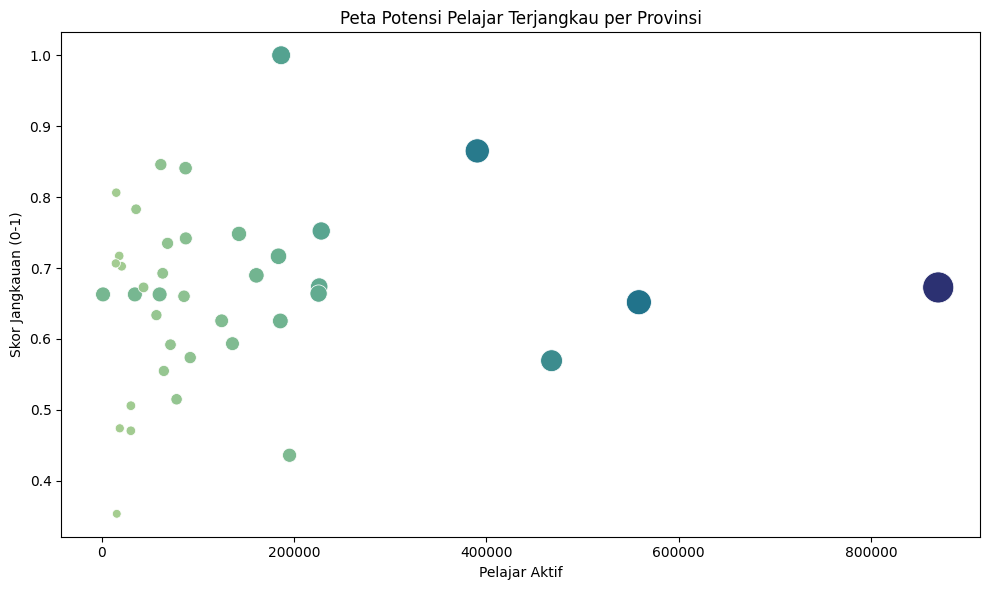

In [ ]:
# Visualisasi 3: Scatter potensi volume vs kesiapan jangkauan sebelum feature engineering
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=analitik_provinsi,
    x='pelajar_aktif',
    y='skor_jangkauan',
    size='estimasi_pelajar_terjangkau',
    hue='estimasi_pelajar_terjangkau',
    sizes=(40, 500),
    palette='crest',
    legend=False,
)
plt.title('Peta Potensi Pelajar Terjangkau per Provinsi')
plt.xlabel('Pelajar Aktif')
plt.ylabel('Skor Jangkauan (0-1)')
plt.tight_layout()
plt.show()

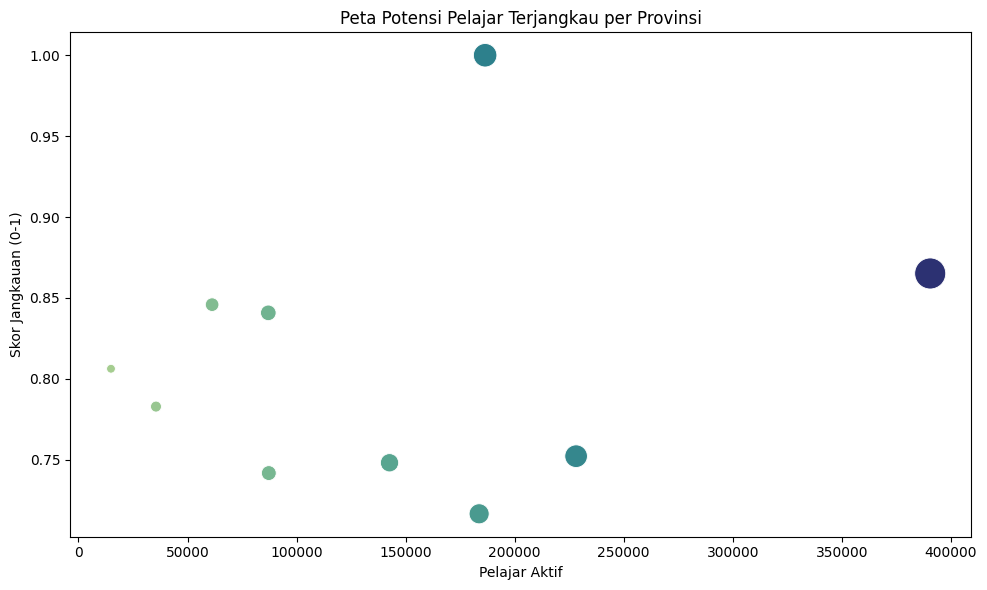

In [76]:
# Visualisasi 3: Scatter potensi volume vs kesiapan jangkauan setelah feature engineering
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=top_prioritas_baru,
    x='pelajar_aktif',
    y='skor_jangkauan',
    size='estimasi_pelajar_terjangkau',
    hue='estimasi_pelajar_terjangkau',
    sizes=(40, 500),
    palette='crest',
    legend=False,
)
plt.title('Peta Potensi Pelajar Terjangkau per Provinsi')
plt.xlabel('Pelajar Aktif')
plt.ylabel('Skor Jangkauan (0-1)')
plt.tight_layout()
plt.show()

## Pembacaan Hasil Visualisasi (Final)

Terdapat perbedaan yang cukup signifikan antara hasil sebelum dan sesudah Feature Engineering (FE). Perbedaan ini menunjukkan bahwa FE membantu menghasilkan representasi fitur yang lebih informatif untuk menentukan prioritas jangkauan.

Pada hasil sebelum FE, provinsi dengan estimasi pelajar terjangkau tertinggi cenderung didominasi provinsi dengan volume pelajar besar. Setelah FE, urutan prioritas dapat bergeser karena kini skor akhir juga mempertimbangkan kondisi dropout melalui skor_dropout_rendah.

Catatan penting interpretasi:
- skor_dropout_rendah adalah skor terbalik dari rasio dropout.
- Nilai skor_dropout_rendah yang lebih tinggi berarti kondisi dropout relatif lebih baik (lebih rendah), bukan lebih buruk.

Heatmap menunjukkan kombinasi indikator kesiapan antar provinsi (pelajar aktif, telepon, internet, sinyal, skor jangkauan), sehingga pembacaan prioritas menjadi lebih kontekstual dan tidak hanya bergantung pada satu indikator saja.

In [82]:
# Audit cepat kualitas data hasil analitik
kolom_kunci = [
    'Provinsi',
    'jumlah_siswa_total',
    'dropout_24_25_25_26',
    'pelajar_aktif',
    'persen_telepon',
    'persen_akses_internet_sma',
    'rasio_sinyal_lte',
    'skor_jangkauan',
    'estimasi_pelajar_terjangkau'
]

print('Jumlah baris analitik_provinsi:', len(analitik_provinsi))
print('Provinsi unik:', analitik_provinsi['Provinsi'].nunique())
print('Duplikat provinsi:', analitik_provinsi['Provinsi'].duplicated().sum())
print('Missing value kolom kunci:')
print(analitik_provinsi[kolom_kunci].isna().sum().to_string())

print('\nRingkas rentang nilai utama:')
print(
    analitik_provinsi[[
        'pelajar_aktif',
        'persen_telepon',
        'persen_akses_internet_sma',
        'rasio_sinyal_lte',
        'skor_jangkauan',
        'estimasi_pelajar_terjangkau'
    ]].describe().loc[['min', 'max', 'mean']].to_string()
)

print('\nCek negatif yang tidak logis:')
print('pelajar_aktif < 0:', int((analitik_provinsi['pelajar_aktif'] < 0).sum()))
print('estimasi_pelajar_terjangkau < 0:', int((analitik_provinsi['estimasi_pelajar_terjangkau'] < 0).sum()))

Jumlah baris analitik_provinsi: 39
Provinsi unik: 39
Duplikat provinsi: 0
Missing value kolom kunci:
Provinsi                       0
jumlah_siswa_total             0
dropout_24_25_25_26            0
pelajar_aktif                  0
persen_telepon                 0
persen_akses_internet_sma      0
rasio_sinyal_lte               0
skor_jangkauan                 0
estimasi_pelajar_terjangkau    0

Ringkas rentang nilai utama:
      pelajar_aktif  persen_telepon  persen_akses_internet_sma  rasio_sinyal_lte  skor_jangkauan  estimasi_pelajar_terjangkau
min     1149.000000       15.760000                  28.610000          0.258048        0.353428                  5455.000000
max   870118.000000       83.430000                  46.990000          1.000000        1.000000                585234.000000
mean  139287.871795       66.282703                  37.134865          0.928790        0.662765                100533.944444

Cek negatif yang tidak logis:
pelajar_aktif < 0: 0
estimasi_pelajar

## Pengenalan A/B Testing untuk Pemula

A/B Testing adalah metode membandingkan dua versi perlakuan untuk melihat mana yang memberi hasil lebih baik.

Dalam konteks project ini:
- Group A (control): skenario baseline/tanpa intervensi tambahan.
- Group B (treatment): skenario dengan intervensi (misalnya peningkatan dukungan digital).

Istilah penting:
- Metrik utama: nilai yang dibandingkan (contoh: `skor_prioritas_baru` atau `estimasi_pelajar_terjangkau`).
- Hipotesis nol (H0): tidak ada perbedaan signifikan antara A dan B.
- Hipotesis alternatif (H1): ada perbedaan signifikan antara A dan B.
- p-value: probabilitas hasil yang diamati jika H0 benar.
- alpha (umumnya 0.05): batas keputusan statistik.

Alur singkat A/B Testing:
1. Tentukan metrik dan hipotesis.
2. Bentuk kelompok A dan B secara adil (random).
3. Hitung performa masing-masing kelompok.
4. Lakukan uji statistik.
5. Ambil keputusan berdasarkan p-value dan dampak bisnis.

Catatan: di notebook ini kita gunakan simulasi sederhana agar konsepnya mudah dipahami.

## Latihan A/B Testing (Isi Titik-Titik)

Isi bagian `...` di setiap cell berikut, lalu jalankan berurutan.

In [94]:
# A/B Testing dalam satu cell (setup -> evaluasi -> kesimpulan)
from scipy import stats

# 1) Setup data eksperimen
ab_data = latihan_fe[['Provinsi', 'skor_prioritas_baru', 'estimasi_pelajar_terjangkau']].copy()
np.random.seed(42)
ab_data['group'] = np.random.choice(['A', 'B'], size=len(ab_data), p=[0.5, 0.5])

metrik_utama = 'skor_prioritas_baru'
uplift_treatment = 0.05

ab_data['metric_experiment'] = ab_data[metrik_utama]
mask_b = ab_data['group'] == 'B'
ab_data.loc[mask_b, 'metric_experiment'] = (
    ab_data.loc[mask_b, metrik_utama] * (1 + uplift_treatment)
)

# 2) Perbandingan performa A vs B
rata_a = ab_data.loc[ab_data['group'] == 'A', 'metric_experiment'].mean()
rata_b = ab_data.loc[ab_data['group'] == 'B', 'metric_experiment'].mean()
selisih = rata_b - rata_a
uplift_persen = (selisih / rata_a) * 100

# 3) Uji statistik (Welch's t-test)
nilai_a = ab_data.loc[ab_data['group'] == 'A', 'metric_experiment']
nilai_b = ab_data.loc[ab_data['group'] == 'B', 'metric_experiment']
alpha = 0.05
t_stat, p_value = stats.ttest_ind(nilai_a, nilai_b, equal_var=False)

# 4) Ringkasan hasil
print('Preview data eksperimen:')
display(ab_data.head())

print('\nRingkasan metrik:')
print('Metrik utama            :', metrik_utama)
print('Rata-rata group A       :', rata_a)
print('Rata-rata group B       :', rata_b)
print('Selisih B - A           :', selisih)
print('Uplift (%)              :', uplift_persen)
print('t-statistic             :', t_stat)
print('p-value                 :', p_value)
print('alpha                   :', alpha)

if p_value < alpha:
    keputusan_statistik = 'Tolak H0 (perbedaan signifikan)'
else:
    keputusan_statistik = 'Gagal tolak H0 (belum ada bukti perbedaan signifikan)'

print('Keputusan statistik     :', keputusan_statistik)

kesimpulan_ab = f"""
1. Metrik yang diuji: {metrik_utama}
2. Performa group B dibanding A: uplift {uplift_persen:.2f}%
3. Hasil statistik: p-value = {p_value:.6f} dan alpha = {alpha}
4. Keputusan implementasi 3-6 bulan: {keputusan_statistik}; perlu validasi lanjutan sebelum implementasi penuh.
"""

print('\nKesimpulan bisnis A/B testing:')
print(kesimpulan_ab)

Preview data eksperimen:


,Provinsi,skor_prioritas_baru,estimasi_pelajar_terjangkau,group,metric_experiment
0,ACEH,0.787700,106690.0,A,0.787700
1,SUMATERA UTARA,0.842371,337838.0,B,0.884489
2,SUMATERA BARAT,0.713384,110831.0,B,0.749053
3,RIAU,0.785890,131636.0,B,0.825185
4,JAMBI,0.749081,56374.0,A,0.749081



Ringkasan metrik:
Metrik utama            : skor_prioritas_baru
Rata-rata group A       : 0.7363561835439074
Rata-rata group B       : 0.7535917595016692
Selisih B - A           : 0.017235575957761817
Uplift (%)              : 2.3406574621008933
t-statistic             : -0.47179785908436855
p-value                 : 0.6404780706370784
alpha                   : 0.05
Keputusan statistik     : Gagal tolak H0 (belum ada bukti perbedaan signifikan)

Kesimpulan bisnis A/B testing:

1. Metrik yang diuji: skor_prioritas_baru
2. Performa group B dibanding A: uplift 2.34%
3. Hasil statistik: p-value = 0.640478 dan alpha = 0.05
4. Keputusan implementasi 3-6 bulan: Gagal tolak H0 (belum ada bukti perbedaan signifikan); perlu validasi lanjutan sebelum implementasi penuh.



## Kesimpulan Jawaban Pertanyaan Bisnis

Berdasarkan analisis data per provinsi, organisasi dapat mengestimasi potensi pelajar yang dapat dijangkau dalam 3-6 bulan melalui kombinasi jumlah pelajar aktif dan skor jangkauan digital. Skor jangkauan dibentuk dari kepemilikan telepon seluler, akses internet jenjang SMA, dan rasio ketersediaan sinyal.

Jika melihat 3 provinsi dengan prioritas tertinggi setelah Feature Engineering, hasilnya adalah:
1. DKI Jakarta: estimasi pelajar terjangkau = 186.451
2. Sulawesi Utara: estimasi pelajar terjangkau = 51.825
3. Kalimantan Timur: estimasi pelajar terjangkau = 73.177

Total estimasi pelajar yang dapat dijangkau dari 3 provinsi teratas tersebut adalah 311.453 pelajar.

Dengan demikian, pertanyaan bisnis utama sudah terjawab: organisasi dapat menyusun prioritas wilayah akuisisi pelajar secara terarah dengan pendekatan berbasis data. Namun, untuk keputusan implementasi intervensi secara penuh, pengujian lanjutan tetap disarankan agar dampak program dapat divalidasi lebih kuat.